In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mimic_base_path = 'C:\\Users\\kai_o\\Documents\\workspace\\uff\\mimic-iii-clinical-database'

In [3]:
prescriptions = pd.read_csv(f'{mimic_base_path}\PRESCRIPTIONS.csv')

C:\Users\kai_o\AppData\Local\Temp\ipykernel_23188\1843772393.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  prescriptions = pd.read_csv(f'{mimic_base_path}\PRESCRIPTIONS.csv')


### Análise exploratória
1. Como os medicamentos são prescritos?
2. Quantos medicamentos simultâneos os pacientes recebem?
3. Qual o nível de variabilidade nos nomes dos medicamentos?
4. Qual o grau de co-prescrição?
5. Existem padrões que sugerem risco de interação?

#### Visão Geral da Tabela Prescriptions

In [4]:
prescriptions.head()

,ROW_ID,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTDATE,ENDDATE,DRUG_TYPE,DRUG,DRUG_NAME_POE,DRUG_NAME_GENERIC,FORMULARY_DRUG_CD,GSN,NDC,PROD_STRENGTH,DOSE_VAL_RX,DOSE_UNIT_RX,FORM_VAL_DISP,FORM_UNIT_DISP,ROUTE
0,2214776,6,107064,NaN,2175-06-11 00:00:00,2175-06-12 00:00:00,MAIN,Tacrolimus,Tacrolimus,Tacrolimus,TACR1,021796,469061711.0,1mg Capsule,2,mg,2,CAP,PO
1,2214775,6,107064,NaN,2175-06-11 00:00:00,2175-06-12 00:00:00,MAIN,Warfarin,Warfarin,Warfarin,WARF5,006562,56017275.0,5mg Tablet,5,mg,1,TAB,PO
2,2215524,6,107064,NaN,2175-06-11 00:00:00,2175-06-12 00:00:00,MAIN,Heparin Sodium,NaN,NaN,HEPAPREMIX,006522,338055002.0,"25,000 unit Premix Bag","25,000",UNIT,1,BAG,IV
3,2216265,6,107064,NaN,2175-06-11 00:00:00,2175-06-12 00:00:00,BASE,D5W,NaN,NaN,HEPBASE,NaN,0.0,HEPARIN BASE,250,ml,250,ml,IV
4,2214773,6,107064,NaN,2175-06-11 00:00:00,2175-06-12 00:00:00,MAIN,Furosemide,Furosemide,Furosemide,FURO20,008208,54829725.0,20mg Tablet,20,mg,1,TAB,PO


In [5]:
prescriptions.shape

(4156450, 19)

In [ ]:
print('Número de pacientes que possuem uma ou mais prescrições: ', prescriptions["SUBJECT_ID"].nunique())
print('Número de internações de pacientes que possuem uma ou mais prescrições: ', prescriptions["HADM_ID"].nunique())

Número de pacientes que possuem uma ou mais prescrições:  39363
Número de admissões de pacientes que possuem uma ou mais prescrições:  50216


In [7]:
prescriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4156450 entries, 0 to 4156449
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ROW_ID             int64  
 1   SUBJECT_ID         int64  
 2   HADM_ID            int64  
 3   ICUSTAY_ID         float64
 4   STARTDATE          object 
 5   ENDDATE            object 
 6   DRUG_TYPE          object 
 7   DRUG               object 
 8   DRUG_NAME_POE      object 
 9   DRUG_NAME_GENERIC  object 
 10  FORMULARY_DRUG_CD  object 
 11  GSN                object 
 12  NDC                float64
 13  PROD_STRENGTH      object 
 14  DOSE_VAL_RX        object 
 15  DOSE_UNIT_RX       object 
 16  FORM_VAL_DISP      object 
 17  FORM_UNIT_DISP     object 
 18  ROUTE              object 
dtypes: float64(2), int64(3), object(14)
memory usage: 602.5+ MB


In [8]:
prescriptions_per_patient = prescriptions.groupby("SUBJECT_ID").size()
prescriptions_per_admission = prescriptions.groupby("HADM_ID").size()

Número de prescrições por paciente

In [9]:
prescriptions_per_patient.describe()

count    39363.000000
mean       105.592816
std        120.689700
min          1.000000
25%         37.000000
50%         74.000000
75%        128.000000
max       2378.000000
dtype: float64

Número de prescrições por internação (admissão)

In [10]:
prescriptions_per_admission.describe()

count    50216.000000
mean        82.771427
std         75.012547
min          1.000000
25%         35.000000
50%         65.000000
75%        105.000000
max       1400.000000
dtype: float64

#### Quantidade de medicamentos únicos

In [33]:
prescriptions_per_admission.head()

HADM_ID
100001     92
100003     29
100006     75
100007     84
100009    122
dtype: int64

In [11]:
print('Número de medicamentos únicos que foram prescritos: ', prescriptions["DRUG"].nunique())

Número de medicamentos únicos que foram prescritos:  4525


In [34]:
# Contagem de medicamentos únicos por internação
polypharmacy = prescriptions.groupby('HADM_ID')['DRUG'].nunique()
polypharmacy.describe()

count   50211.00
mean       34.95
std        18.17
min         1.00
25%        22.00
50%        33.00
75%        46.00
max       173.00
Name: DRUG, dtype: float64

In [42]:
polypharmacy.head()

HADM_ID
100001    37
100003    23
100006    37
100007    39
100009    49
Name: DRUG, dtype: int64

In [45]:
polypharmacy.shape

(50211,)

In [43]:
polypharmacy.value_counts().head(10)

DRUG
24    1221
25    1160
30    1153
29    1150
26    1149
28    1142
31    1136
23    1108
4     1102
32    1090
Name: count, dtype: int64

Média de medicamentos por internação: 34.95


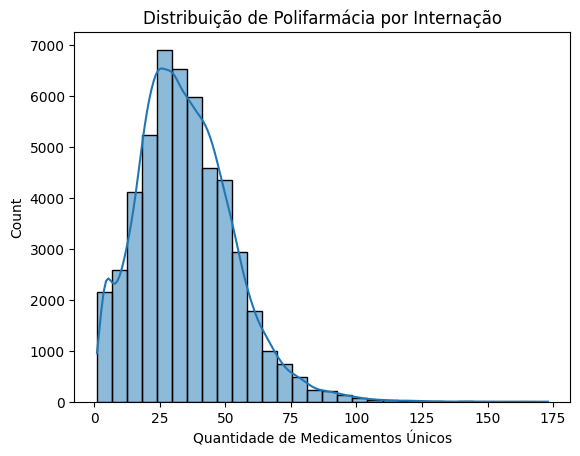

In [51]:
print(f"Média de medicamentos por internação: {polypharmacy.mean():.2f}")
sns.histplot(polypharmacy, bins=30, kde=True)
plt.title('Distribuição de Polifarmácia por Internação')
plt.xlabel('Quantidade de Medicamentos Únicos')
plt.show()

#### Distribuição de frequência dos medicamentos

In [12]:
drug_counts = prescriptions['DRUG'].value_counts()
drug_counts.head(20)

DRUG
Potassium Chloride             192993
Insulin                        143465
D5W                            142241
Furosemide                     133122
0.9% Sodium Chloride           130147
NS                             129731
Magnesium Sulfate               90427
Iso-Osmotic Dextrose            87005
Sodium Chloride 0.9%  Flush     83392
Acetaminophen                   78768
Metoprolol                      73986
5% Dextrose                     73829
SW                              72522
Morphine Sulfate                62134
Metoprolol Tartrate             59824
Lorazepam                       55352
Calcium Gluconate               52110
Heparin                         52069
Docusate Sodium                 45694
Vancomycin                      42634
Name: count, dtype: int64

#### Duração das prescrições

In [13]:
prescriptions["STARTDATE"] = pd.to_datetime(prescriptions["STARTDATE"])
prescriptions["ENDDATE"] = pd.to_datetime(prescriptions["ENDDATE"])

Dados hospitalares reais frequentemente contêm erros. Para o cálculo da duração da prescrição, precisamos filtrar os casos em que `ENDDATE < STARTDATE`, removendo esses registros da análise por serem inconsistentes.

In [14]:
prescriptions = prescriptions[
    prescriptions["ENDDATE"] >= prescriptions["STARTDATE"]
]

Foram removidos 21.540 registros

In [15]:
prescriptions.shape

(4134910, 19)

In [16]:
# Duração em horas
prescriptions["DURATION"] = (
    prescriptions["ENDDATE"] - prescriptions["STARTDATE"]
).dt.total_seconds() / 3600

In [17]:
prescriptions["DURATION"].value_counts()

DURATION
24.0       1557704
0.0         856103
48.0        470431
72.0        319407
96.0        212737
            ...   
3336.0           1
8280.0           1
8616.0           1
87648.0          1
17616.0          1
Name: count, Length: 177, dtype: int64

In [18]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [19]:
prescriptions["DURATION"].describe()

count   4134910.00
mean         69.11
std         439.59
min           0.00
25%          24.00
50%          24.00
75%          72.00
max      841656.00
Name: DURATION, dtype: float64

In [20]:
prescriptions["DURATION_DAYS"] = prescriptions["DURATION"] / 24

In [21]:
prescriptions["DURATION_DAYS"].value_counts()

DURATION_DAYS
1.00       1557704
0.00        856103
2.00        470431
3.00        319407
4.00        212737
            ...   
139.00           1
345.00           1
359.00           1
3652.00          1
734.00           1
Name: count, Length: 177, dtype: int64

In [22]:
prescriptions["DURATION_DAYS"].describe()

count   4134910.00
mean          2.88
std          18.32
min           0.00
25%           1.00
50%           1.00
75%           3.00
max       35069.00
Name: DURATION_DAYS, dtype: float64

In [23]:
invalid = prescriptions[prescriptions["DURATION_DAYS"] > 30]
len(invalid)

22380

In [31]:
polypharmacy.describe()

count   50211.00
mean       34.95
std        18.17
min         1.00
25%        22.00
50%        33.00
75%        46.00
max       173.00
Name: DRUG, dtype: float64

In [ ]:
aspirina_rows = prescriptions[prescriptions['DRUG'].str.contains('Aspirin', case=False, na=False)]

In [ ]:
aspirina_rows

,ROW_ID,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTDATE,ENDDATE,DRUG_TYPE,DRUG,DRUG_NAME_POE,DRUG_NAME_GENERIC,FORMULARY_DRUG_CD,GSN,NDC,PROD_STRENGTH,DOSE_VAL_RX,DOSE_UNIT_RX,FORM_VAL_DISP,FORM_UNIT_DISP,ROUTE
354,2122366,13,143045,NaN,2167-01-08 00:00:00,2167-01-09 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASAEC325,004381,1.771400e+10,325mg Tab,325,mg,1,TAB,PO
451,2123137,13,143045,263738.0,2167-01-09 00:00:00,2167-01-12 00:00:00,MAIN,Aspirin,Aspirin,Aspirin,ASA325,004376,5.107900e+10,325mg Tab,325,mg,1,TAB,NG
452,2123136,13,143045,263738.0,2167-01-09 00:00:00,2167-01-12 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASAEC325,004381,1.771400e+10,325mg Tab,325,mg,1,TAB,PO
471,2123163,13,143045,263738.0,2167-01-12 00:00:00,2167-01-15 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASAEC325,004381,1.771400e+10,325mg Tab,325,mg,1,TAB,PO
495,710315,17,194023,NaN,2134-12-27 00:00:00,2134-12-29 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASA81EC,016995,9.047704e+08,81mg EC Tab,81,mg,1,TAB,PO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4155791,3837247,99138,148579,273748.0,2146-11-10 00:00:00,2146-11-13 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASA81EC,016995,6.373903e+10,81mg EC Tab,81,mg,1,TAB,PO
4155946,845976,98931,133126,NaN,2167-03-13 00:00:00,2167-03-20 00:00:00,MAIN,Aspirin,Aspirin,Aspirin,ASA81,004380,9.044041e+08,81mg Tab,81,mg,1,TAB,PO/NG
4156251,3726502,98959,116420,298632.0,2142-01-06 00:00:00,2142-01-09 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASA81EC,016995,6.373903e+10,81mg EC Tab,81,mg,1,TAB,PO
4156340,228647,99017,103056,NaN,2176-07-08 00:00:00,2176-07-10 00:00:00,MAIN,Aspirin EC,Aspirin EC,Aspirin EC,ASAEC325,004381,1.771400e+10,325mg Tab,325,mg,1,TAB,PO


In [ ]:
prescriptions.head()

,SUBJECT_ID,HADM_ID,STARTDATE,ENDDATE,DRUG
0,6,107064,2175-06-11,2175-06-12,Tacrolimus
1,6,107064,2175-06-11,2175-06-12,Warfarin
2,6,107064,2175-06-11,2175-06-12,Heparin Sodium
3,6,107064,2175-06-11,2175-06-12,D5W
4,6,107064,2175-06-11,2175-06-12,Furosemide
